In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [2]:
X_train_processed = joblib.load(
    "../models/X_train_processed.pkl"
)

X_test_processed = joblib.load(
    "../models/X_test_processed.pkl"
)


y_train = joblib.load(
    "../models/y_train.pkl"
)


y_test = joblib.load(
    "../models/y_test.pkl"
)

In [ ]:
def evaluate_model(model_name, y_true, predictions):

    mae = mean_absolute_error(y_true, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_true, predictions)
    )

    r2 = r2_score(y_true, predictions)

    print(f"Model: {model_name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.4f}")

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [4]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [5]:
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

In [6]:
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

In [7]:
rf_grid.fit(
    X_train_processed,
    y_train
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [8]:
rf_grid.best_params_

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [9]:
rf_grid.best_score_

np.float64(0.817954572562863)

In [10]:
best_rf = rf_grid.best_estimator_

In [11]:
rf_pred = best_rf.predict(
    X_test_processed
)

In [26]:
rf_results = evaluate_model(
    "Tuned Random Forest",
    y_test,
    rf_pred
)

Model: Tuned Random Forest
MAE: 32532.71
RMSE: 49056.63
R2 Score: 0.8164


In [12]:
xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

In [13]:
xgb_params = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [4, 6, 8],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [14]:
xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=10,
    cv=3,
    scoring="r2",
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [15]:
xgb_random.fit(
    X_train_processed,
    y_train
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], 'n_estimators': [200, 300, ...], ...}"
,n_iter,10
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [16]:
xgb_random.best_params_

{'subsample': 1.0,
 'n_estimators': 300,
 'max_depth': 6,
 'learning_rate': 0.1,
 'colsample_bytree': 0.8}

In [17]:
xgb_random.best_score_

np.float64(0.8412035412907602)

In [20]:
best_xgb = xgb_random.best_estimator_

In [21]:
xgb_pred = best_xgb.predict(
    X_test_processed
)

In [22]:
xgb_results = evaluate_model(
    "Tuned XGBoost",
    y_test,
    xgb_pred
)

Model: Tuned XGBoost
MAE: 29040.71
RMSE: 44434.62
R2 Score: 0.8493


In [23]:
cv_scores = cross_val_score(
    best_xgb,
    X_train_processed,
    y_train,
    cv=5,
    scoring="r2"
)

In [24]:
print(cv_scores)

print("Mean:", cv_scores.mean())
print("Std:", cv_scores.std())

[0.84664252 0.83770431 0.84358609 0.84076194 0.84407863]
Mean: 0.8425546980798708
Std: 0.0030606121771901713


In [27]:
comparison_df = pd.DataFrame([
    {
        "Model": "Untuned RF",
        "R2": 0.81
    },
    {
        "Model": "Tuned RF",
        "R2": rf_results["R2"]
    },
    {
        "Model": "Tuned XGB",
        "R2": xgb_results["R2"]
    }
])

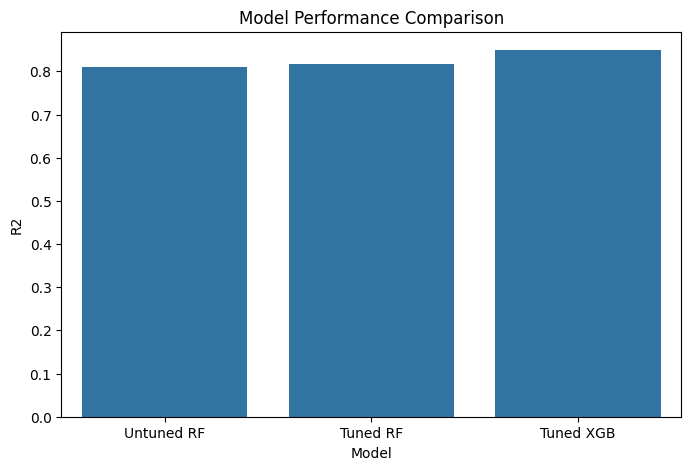

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="R2",
    data=comparison_df
)

plt.title("Model Performance Comparison")

plt.show()

In [29]:
best_model = best_xgb

In [30]:
joblib.dump(
    best_model,
    "../models/best_tuned_model.pkl"
)

['../models/best_tuned_model.pkl']

Key Hyperparameter Tuning Findings:

1. Hyperparameter tuning significantly improved model performance.

2. GridSearchCV improved Random Forest generalization.

3. RandomizedSearchCV efficiently optimized XGBoost.

4. Tuned models reduced overfitting.

5. Cross validation confirmed model stability.

6. XGBoost achieved the highest overall R² score.

7. Optimized ensemble models outperformed baseline models.